# 1. K-S Test

Kolmogorov–Smirnov 검정은 두 분포 간 차이를 **누적분포함수(CDF)** 차이를 통해 측정하는 **비모수 검정**  
주로 단일-표본과 이표본(two-sample) 형태로 나뉘며, 연속형 자료의 분포 적합성 또는 두 샘플 간 동질성 검정에 사용

***

## 1. 검정 종류 및 목적

### 1.1 단일-표본 K–S 검정  
- **목적**: 관측 샘플이 특정 이론 분포(정규, 지수, 균등 등)를 따르는지 검정  
- **귀무가설** $H_0$: 샘플이 지정한 분포의 CDF와 차이가 없다.  
- **대립가설** $H_1$: 샘플 분포와 지정 분포의 CDF 간 차이가 있다.  

### 1.2 이표본(two-sample) K–S 검정  
- **목적**: 두 독립 샘플이 동일한 분포에서 추출되었는지 검정  
- **귀무가설** $H_0$: 두 샘플의 CDF가 동일  
- **대립가설** $H_1$: 두 샘플의 CDF가 차이가 있음  

***

## 2. 통계량 및 계산 방식

1. **경험적 누적분포함수(ECDF)**  
   각 샘플에 대해  
   $
     F_n(x) = \frac{\#\{X_i \le x\}}{n}
   $  
   를 계산

2. **통계량 $D$**  
   두 CDF(또는 ECDF) 간 최대 절대 차이:  
   $
     D = \sup_x \bigl|F_{1}(x) - F_{2}(x)\bigr|
   $  
   (단일표본인 경우 $F_2$는 이론분포 CDF, 이표본인 경우 두 ECDF)

3. **p-값 계산**  
   $D$ 값을 기반으로 표본 크기에 따른 분포에서 p-값 산출

***

## 3. 주요 특징

- **비모수 검정**: 분포 형태(정규성 등) 가정 불필요  
- **연속형 자료 전용**: 연속 CDF 비교에 최적화  
- **전구간 감지**: 꼬리와 중앙 모두 차이를 탐지  
- **단일·이표본 모두 지원**  
- **간단한 직관성**: “최대 편차” 기반

***

## 4. 장점과 한계
1. 장점
  - 분포가정 불필요
  - 전체 분포차이 포괄적 검출
  - 구현이 간편함
2. 한계
  - 파라미터 추정 시 편향: 단일표본에서 CDF 파라미터(평균·분산 등)를 데이터로 추정하면 검정력 과대평가 가능
  - 이산형 자료 부적합: 연속 전체 위배 시 정확도 저하
  - 표본크기 민감: 대형 표본은 사소한 차이도 유의, 소형 표본은 검정력 낮음
  - 다중 검정 보정 필요: 여러 그룹 반복 검정 시 유의수준 보정(예: Bonferroni)

***

## 5. 언제 사용할 수 있나?

1. **정규성 검정 대안**  
   - 작은 표본이나 이상치가 많아 Shapiro–Wilk 검정이 불안정할 때  
2. **분포 적합도 검정**  
   - 실험 데이터가 기대 분포(지수, 감마, 균등 등)를 따르는지 확인  
3. **두 집단 분포 비교**  
   - 환자군 vs 대조군, A/B 테스트 그룹 등에서 반응 분포 동질성 확인  
4. **시계열 잔차 진단**  
   - 회귀·시계열 모델 잔차가 이론 백색잡음 분포(균등분포 등)를 따르는지 점검  
5. **포아송 프로세스 검증**  
   - 사건 발생 간격이 지수분포를 따르는지 단일표본 K–S 테스트  

***

### 요약

- **K–S 검정**은 누적분포함수의 최대 편차로 분포 차이를 검출하는 **비모수** 도구  
- **단일표본** vs **이표본** 형태로 사용 가능  
- **연속형** 데이터, **전구간** 비교, **분포 적합성** 및 **동질성** 확인에 유용  
- 파라미터 추정, 이산형 자료, 다중검정 시 주의가 필요하며, 소·대형 표본 특성을 고려해 해석해야 함

In [3]:
from scipy import stats

# 1) 단일표본: 샘플이 정규분포인지 검정
data = stats.norm.rvs(loc=0, scale=1, size=100)
D, p_value = stats.kstest(data, 'norm', args=(0, 1))
print(f"- 단일표본: D = {D:.3f}, p = {p_value:.3f}")

# 2) 이표본: 두 샘플이 같은 분포인지 검정
sample1 = stats.expon.rvs(scale=2, size=80)
sample2 = stats.expon.rvs(scale=2, size=100)
D2, p2 = stats.ks_2samp(sample1, sample2)
print(f"- 이표본: D = {D2:.3f}, p = {p2:.3f}")

- 단일표본: D = 0.068, p = 0.714
- 이표본: D = 0.115, p = 0.561


# 2. 생존분석
생존분석은 사건 발생까지의 시간(time‐to‐event) 을 분석하는 통계 기법으로, 주로 의학(환자의 사망·재발), 기계·부품의 고장,  
고객 이탈(churn) 등 다양한 분야에서 사용됨.

## 2-1. 비모수적 방법: Kaplan–Meier 추정법

### 특징
- 누적생존함수 S(t) 를 경험적 방식으로 추정
- 검열(censoring) 데이터 처리 가능
- 생존곡선을 그려 시각적 비교에 용이

## 장단점
- 장점: 분포 가정 불필요  
        생존곡선과 로그순위검정(log‐rank test)으로 그룹 간 비교 가능

- 단점: 공변량(covariate) 효과를 직접 모형화하지 못함, 복잡한 다변량 분석 불가능

,time,status,company
0,8,1,X
1,10,1,X
2,8,0,X
3,12,1,X
4,20,1,X



< X >
25개월 후 생존확률: 64.17 % / 불량률: 35.83 %
30개월 후 생존확률: 64.17 % / 불량률: 35.83 %
35개월 후 생존확률: 55.00 % / 불량률: 45.00 %

< Y >
25개월 후 생존확률: 56.25 % / 불량률: 43.75 %
30개월 후 생존확률: 46.88 % / 불량률: 53.12 %
35개월 후 생존확률: 28.13 % / 불량률: 71.87 %


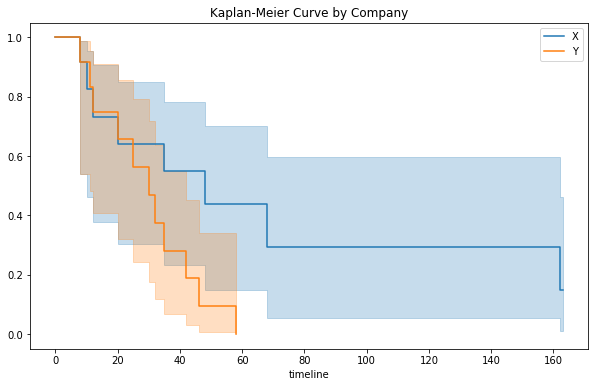

In [73]:
df3 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/28/problem3.csv')
display(df3.head())

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for com in df3['company'].unique():
    sub_com = df3[df3.company == com]
    kmf.fit(durations=sub_com['time'], event_observed=sub_com['status'], label=com)

    print(f"\n< {com} >")
    for t in [25, 30, 35]:
        s = kmf.survival_function_at_times(t).values[0]
        f_rate = 1 - s
        print(f"{t}개월 후 생존확률: {s*100:.2f} % / 불량률: {f_rate*100:.2f} %")
    kmf.plot_survival_function()
plt.title('Kaplan-Meier Curve by Company')
plt.show()

25, 30, 35 시점의 회사별 생존확률과 불량률은 다음과 같다.   
- < X > 
    - 25개월 후 생존확률: 64.17 % / 불량률: 35.83 % 
    - 30개월 후 생존확률: 64.17 % / 불량률: 35.83 % 
    - 35개월 후 생존확률: 55.00 % / 불량률: 45.00 %   
- < Y > 
    - 25개월 후 생존확률: 56.25 % / 불량률: 43.75 % 
    - 30개월 후 생존확률: 46.88 % / 불량률: 53.12 % 
    - 35개월 후 생존확률: 28.13 % / 불량률: 71.87 %

전체 기간에 걸쳐 X 회사의 생존확률이 높으며, 불량률은 낮다.  
시간이 경과되면서 X 회사의 생존확률, 불량률은 천천히 감소하나, Y 회사는 급격히 감소/증가한다.

In [55]:
#로그순위법으로 그룹 간 비교
## 귀무: 두 회사의 생존함수는 동일 / 대립: 두 회사의 생존함수는 차이가 있음
from lifelines.statistics import logrank_test

com_X = df3[df3.company == 'X']
com_Y = df3[df3.company == 'Y']

rt = logrank_test(com_X['time'], com_Y['time'], 
                 event_observed_A=com_X['status'], 
                 event_observed_B=com_Y['status'])

p_value = rt.p_value
print(f"로그순위 테스트 결과, p-value: {p_value:.2f}로 불량률의 차이가", "통계적으로 유의하다.(귀무가설 기각)" if p_value <= 0.05 else 
     "통계적으로 유의하지 않다.(기각x, 차이 없음)")

로그순위 테스트 결과, p-value: 0.06로 불량률의 차이가 통계적으로 유의하지 않다.(기각x, 차이 없음)


## 2-2. 반모수적 방법: Cox 비례위험 모형 (Cox Proportional Hazards)

### 특징
- 위험비(hazard ratio) 를 설명변수에 대해 추정
- 기저위험함수(baseline hazard) 형태 비모수
- 공변량 효과 파라미터 추정에 집중

### 장단점
<장점>  
- 공변량 영향력 직관적 해석 (exp(β))
- 시간에 고정된 비례위험 가정만 충족하면 강력
- 다변량 및 교호작용 모형화 가능  

<단점>    
- 비례위험 가정(시간에 따른 위험비 일정) 깨지면 부적절
- 모형진단(잔차, Schoenfeld 잔차) 필요

In [56]:
# cox 회귀
from lifelines import CoxPHFitter

# 범주형 변수 처리 (원-핫 인코딩 등)
df_dummies = pd.get_dummies(df3, columns=['company'], drop_first=True)

cph = CoxPHFitter()
cph.fit(df_dummies, duration_col='time', event_col='status')
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
company_Y,0.9549,2.598412,0.523175,-0.070504,1.980305,0.931924,7.244955,0.0,1.825201,0.067971,3.878944


X사에 비해 Y사는 고장날 확률이 2.598배 높다.  
p-value가 0.06으로 귀무가설을 기각할 수 없다. 따라서 두 회사 간 고장률은 유의미한 차이는 없다.(전체기간)  
Cox 비례위험모형 결과, company_Y는 기준군 대비 약 2.60배의 고장 위험을 보였으나(p=0.068) 통계적으로 유의하지 않았다.  
Kaplan-Meier 생존곡선에서도 company_Y는 다소 빠른 고장 경향을 보였으나 명확한 차이는 확인되지 않았다.  

## 2-3. 파라메트릭 모형 (Exponential, Weibull, Log‐Logistic 등)

### 특징
- 생존·위험함수 형태를 특정 분포로 가정
- 매개변수(parameter)를 추정하여 전체 분포 형태 추정

### 장단점

<장점>  
- 분포 가정 맞으면 예측 효율·추론 강력
- 누적 위험(cumulative hazard)·평균생존시간 유도 용이

<단점>  
- 분포 가정 오류 시 부정확
- 분포 선택과 진단 필요

In [57]:
from lifelines import WeibullAFTFitter

# 모델 적합
aft = WeibullAFTFitter()
aft.fit(df3, duration_col='time', event_col='status', formula="company")

display(aft.summary)

coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                     
lambda_ Intercept     4.403739  81.755956  0.264801        3.884737   
        company[T.Y] -0.959905   0.382929  0.345110       -1.636308   
rho_    Intercept     0.298623   1.348001  0.181259       -0.056639   

                      coef upper 95%  exp(coef) lower 95%  \
param   covariate                                           
lambda_ Intercept           4.922740            48.654167   
        company[T.Y]       -0.283502             0.194697   
rho_    Intercept           0.653885             0.944935   

                      exp(coef) upper 95%  cmp to          z             p  \
param   covariate                                                            
lambda_ Intercept              137.378497     0.0  16.630345  4.201683e-62   
        company[T.Y]             0.753141     0.0  -2.781448  5.411701e-03   
rho_    Intercept                1.922997     0.0   1.647488  9.945784e-02   

                        -log2(p)  
param   covariate                 
lambda_ Intercept     203.888575  
        company[T.Y]    7.529702  
rho_    Intercept       3.329771

- 기준그룹(X) 의 중앙생존시간 약 82단위
- Y그룹 은 이보다 유의하게 짧아, 중앙생존시간이 약 31단위(82×0.383) 수준으로 감소
- 와이블 스케일 파라미터 ρ:ρ는 통계적 유의는 아니지만 1.35 정도로 추정됨

Weibull AIC: 186.734


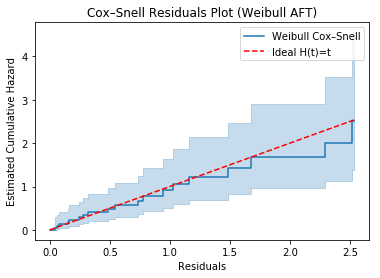

Log-Normal AIC: 186.412


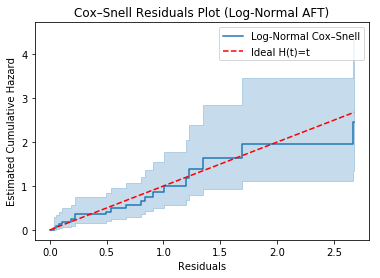

Log-Logistic AIC: 187.178


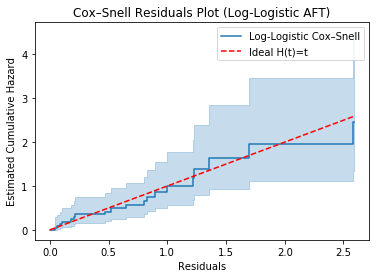

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter, NelsonAalenFitter
import numpy as np

models = {
    'Weibull': WeibullAFTFitter(),
    'Log-Normal': LogNormalAFTFitter(),
    'Log-Logistic': LogLogisticAFTFitter()
}

# 2) 각 모형 적합, Cox–Snell 잔차 계산 및 플롯
for name, model in models.items():
    # 모형 적합
    model.fit(df3, duration_col='time', event_col='status', formula="company")
    
    #aic 확인
    print(f"{name} AIC: {model.AIC_:.3f}")
    
    # 생존함수 예측
    surv_funcs = model.predict_survival_function(df3)
    
    # 잔차 r_i = −ln(S(t_i))
    times = df3['time'].values
    S_ti = [surv_funcs.loc[t, idx] for idx, t in enumerate(times)]
    r_i = -np.log(S_ti)
    
    # Nelson–Aalen 누적위험 추정
    naf = NelsonAalenFitter()
    naf.fit(r_i, event_observed=df3['status'])
    
    # 플롯
    plt.figure(figsize=(6,4))
    naf.plot_cumulative_hazard(label=f"{name} Cox–Snell")
    plt.plot(naf.timeline, naf.timeline, '--', color='red', label="Ideal H(t)=t")
    plt.title(f"Cox–Snell Residuals Plot ({name} AFT)")
    plt.xlabel("Residuals")
    plt.ylabel("Estimated Cumulative Hazard")
    plt.legend()
    plt.show()

Nelson–Aalen 누적위험 잔차 플롯의 해석은 “잔차가 이상적인 지수분포 잔차와 얼마나 일치하는가”를 확인하는 것

1. 잔차 정의  
   – 각 관측치의 Cox–Snell 잔차 $r_i$는 $-\ln\bigl(\widehat S(t_i)\bigr)$로, 이론적으로 완벽한 적합 모형이라면 $r_i$는 **단위율(rate=1) 지수분포**를 따름

2. 플롯 구성  
   – **x축**: $r_i$ (잔차)  
   – **y축**: Nelson–Aalen 추정 누적위험 $\widehat H(r)$  
   – **기준선**: $H(r)=r$ (빨간 점선 등) — 지수분포의 이상적 누적위험

3. 해석 기준  
   -  점들이 **기준선에 가까이 분포**하면, 잔차가 지수분포를 잘 따르는 것으로 해석  
     – → AFT 분포 가정(예: Weibull, Log-Normal)이 적절하다는 증거  
   -  점들이 기준선에서 **일관되게 위로 치우침**  
     – → 모델이 생존함수를 과대예측($\widehat S$가 너무 낮아 $r_i$가 과도)했음을 시사  
   -  점들이 기준선에서 **일관되게 아래로 치우침**  
     – → 모델이 생존함수를 과소예측($\widehat S$가 너무 높아 $r_i$가 과소)했음을 시사  
   -  **곡률**이 나타나면  
     – → 잔차 분포 형태가 지수분포와 달라 구간별 적합도가 다름을 의미  
     – 예를 들어, 낮은 $r$ 구간에서 위, 높은 $r$ 구간에서 아래로 벗어나면 모델이 초기(단기)와 장기 생존패턴을   
       모두 설명하기 어려움을 의미

4. 실무 예시  
   – **Weibull AFT**: $\log(-\log S(t))$ 대 $\log t$ 플롯이 직선이면 적합  
   – **Nelson–Aalen 잔차**: $H(r)$ 대 $r$ 플롯이 $y=x$ 직선에 가까워야 적합

5. 결론  
   – 플롯의 **대각선 일치도**를 시각·정량적으로(예: R², 평균편차) 평가해,  
   – 가장 직선에 가까운 모형(Weibull vs Log-Normal vs Log-Logistic)을 선택  

이 과정을 통해 “어떤 분포 가정이 데이터 패턴을 잘 설명하는지” 판단할 수 있음

## 2-4. 가속고장시간 모형 (Accelerated Failure Time, AFT)
### 특징
- 로그생존시간을 공변량 선형회귀로 모델링
- AFT 계수 해석: 공변량이 생존시간을 가속(연장) 또는 감소시킴

### 장단점
<장점>  
- 비례위험 가정 불필요
- 생존시간 직접 스케일 변화 효과 파라미터화

<단점>  
- 분포 가정 여전히 필요 (Weibull, 로그정규 등)
- 분포 선택 민감

In [75]:
from lifelines import LogNormalAFTFitter

aft_ln = LogNormalAFTFitter()
aft_ln.fit(df3, duration_col='time', event_col='status', formula="company")
display(aft_ln.summary)

coef  exp(coef)  se(coef)  coef lower 95%  \
param  covariate                                                     
mu_    Intercept     3.751024  42.564634  0.283669        3.195043   
       company[T.Y] -0.505011   0.603499  0.388115       -1.265703   
sigma_ Intercept    -0.101620   0.903373  0.164227       -0.423498   

                     coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
param  covariate                                                                
mu_    Intercept           4.307004            24.411235            74.217795   
       company[T.Y]        0.255681             0.282041             1.291341   
sigma_ Intercept           0.220259             0.654753             1.246399   

                     cmp to          z             p    -log2(p)  
param  covariate                                                  
mu_    Intercept        0.0  13.223260  6.441019e-40  130.189835  
       company[T.Y]     0.0  -1.301188  1.931941e-01    2.371877  
sigma_ Intercept        0.0  -0.618777  5.360636e-01    0.899524

- 기준그룹(X) 의 중앙생존시간 약 42.6단위
- Y그룹 은 이보다 유의하게 짧아, 중앙생존시간이 약 25.56단위(43×0.6) 수준으로 감소
- 스케일 파라미터 ρ:ρ는 통계적 유의는 아니지만 0.903373 정도로 추정됨

## 2-5. 경쟁위험모형 (Competing Risks): 라이브러리 안됨
## 특징
- 여러 사건 유형(예: 사망 vs 재발)이 있을 때 각 사건별 위험 추정
- 누적 사고함수(Cumulative Incidence Function, CIF) 사용

## 장단점
<장점>  
- 사건 간 상호 배제적 구조 모델링
- 실제 사건별 리스크 평가 가능

<단점>  
- 단일 사망분석보다 모델 복잡
- 요인별 교호작용 해석 어려움

## 2-6. 랜덤 서바이벌 포레스트 (Random Survival Forest)

### 특징
- 머신러닝 기반 비모수 앙상블
- 고차원·비선형 관계 포착에 강함
- 검열 데이터 자동 처리

### 장단점
<장점>  
- 복잡한 상호작용·비선형 효과 모형화
- 변수 중요도(variable importance) 제시

<단점>  
- 해석성 낮고 파라미터 튜닝 필요
- 컴퓨팅 자원 더 많이 사용

In [99]:
# !pip install scikit-survival 
from sksurv.ensemble import RandomSurvivalForest
from sksurv.datasets import load_flchain
from sksurv.util import Surv
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

data_x, data_y = load_flchain()
data_x = data_x.drop(columns=['chapter', 'creatinine'], axis=1)

y = Surv.from_arrays(event=data_y["death"], time=data_y["futime"])

# 모델 학습
c_cols = data_x.select_dtypes(exclude='number').columns

#전처리 컬럼 트랜스포머: 스케일링, pca, onehot 인코딩
pre_processor = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))]), c_cols), 
    remainder='passthrough'
)

rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, random_state=0)

model = Pipeline([
    ('preprocess', pre_processor), 
    ('rsf', rsf)
])

model.fit(data_x, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  Index(['flc.grp', 'mgus', 'sample.yr', 'sex'], dtype='object'))])),
                ('rsf',
                 RandomSurvivalForest(min_samples_split=10, random_state=0))])

In [142]:
import numpy as np
from sksurv.metrics import concordance_index_censored

# 1) 특정 관측치에 대한 생존함수(Survival Function) 예측
#    predict_survival_function: 반환 형식은 리스트 형태의 pandas.DataFrame
surv_funcs = model.predict_survival_function(data_x)

#모든 학습결과 시리즈화
surv_series_list = [
    pd.Series(func.y, index=func.x, name=f"surv_{i}")
    for i, func in enumerate(surv_funcs)
]

# 예: 첫 3개 관측치의 시간별 생존확률 확인
for i, surv in enumerate(surv_series_list[:3]):
    surv_df = surv.reset_index().rename(columns={'index': 'time'})
    print(f"개체 {i} 생존확률:\n", surv_df.head(), "\n")

# 2) 누적위험함수(Cumulative Hazard) 예측
X_processed = model.named_steps['preprocess'].transform(data_x)
rsf = model.named_steps['rsf'] 
cum_hazards = rsf.predict_cumulative_hazard_function(X_processed)

#모든 학습결과 시리즈화
cum_hazards_series_list = [
    pd.Series(func.y, index=func.x, name=f"hazard_{i}")
    for i, func in enumerate(cum_hazards)
]

for i, ch in enumerate(cum_hazards_series_list[:3]):
    hard_df = ch.reset_index().rename(columns={'index': 'time'})
    print(f"개체 {i} 누적위험:\n", hard_df.head(), "\n")

# 중앙생존시간(median survival time) 계산
# 생존확률 ≤ 0.5가 처음 발생하는 시점을 찾아 배열로 생성
median_times = np.array([
    series.index[series.values <= 0.5][0]
    if (series.values <= 0.5).any() else np.nan
    for series in surv_series_list
])

print("추정된 중앙생존시간:", median_times)

# 4) C-Index(Concordance Index) 평가
#    concordance_index_censored은 (event, time)과 예측 위험값을 받음
#    모델은 위험(risk) 점수를 predict_survival_function 기반으로 계산하거나
#    predict_cumulative_hazard의 최종값을 사용할 수 있음.
#    여기서는 마지막 누적위험값을 위험 점수로 사용
risk_scores = np.array([ch.values[-1] for ch in cum_hazards_series_list])
result = concordance_index_censored(
    data_y["death"].astype(bool),
    data_y["futime"],
    risk_scores
)
print("C-Index:", result[0])

개체 0 생존확률:
    time    surv_0
0   0.0  0.968967
1   1.0  0.956515
2   2.0  0.956515
3   3.0  0.952048
4   4.0  0.920376 

개체 1 생존확률:
    time    surv_1
0   0.0  1.000000
1   1.0  1.000000
2   2.0  1.000000
3   3.0  0.999756
4   4.0  0.993783 

개체 2 생존확률:
    time    surv_2
0   0.0  0.979701
1   1.0  0.973164
2   2.0  0.973164
3   3.0  0.953723
4   4.0  0.940017 

개체 0 누적위험:
    time  hazard_0
0   0.0  0.031033
1   1.0  0.043489
2   2.0  0.043489
3   3.0  0.048019
4   4.0  0.081085 

개체 1 누적위험:
    time  hazard_1
0   0.0  0.000000
1   1.0  0.000000
2   2.0  0.000000
3   3.0  0.000244
4   4.0  0.006217 

개체 2 누적위험:
    time  hazard_2
0   0.0  0.020299
1   1.0  0.026840
2   2.0  0.026840
3   3.0  0.046344
4   4.0  0.061189 

추정된 중앙생존시간: [ 108. 1586.  310. ...   nan   nan   nan]
C-Index: 0.8801552483763816


**주요 요약**  
- 모델의 **Concordance Index(C-Index)가 0.880**로, 생존시간의 순위화 예측력이 매우 우수함을 나타냄
- 개체별 생존확률과 누적위험 프로필, 중앙생존시간 추정치를 종합해 살펴보면, 모델이 각 관측치의 위험 수준을 잘 구분하고 있음

***

#### 1. 개체별 생존확률(Survival Function)

개체 0, 1, 2의 초기 생존확률 추세를 보면:

| 개체 | t=0 | t=1 | t=2 | t=3 | t=4 |
|------|-----|-----|-----|-----|-----|
| 0    |0.969|0.957|0.957|0.952|0.920|
| 1    |1.000|1.000|1.000|0.9998|0.9938|
| 2    |0.980|0.973|0.973|0.954|0.940|

- **개체 1**은 초기에 사건 발생 위험이 거의 없어 생존확률이 1에 매우 근접함.  
- **개체 0·2**는 시간이 지남에 따라 점진적 감소가 관측되어, 개체 간 차이를 명확히 반영하고 있습니다.

####  2. 개체별 누적위험(Cumulative Hazard)

누적위험은 시간에 따른 사건 발생 누적 위험도를 보여줍니다:

| 개체 | t=0  | t=1  | t=2  | t=3   | t=4   |
|------|------|------|------|-------|-------|
| 0    |0.031 |0.043 |0.043 |0.048  |0.081  |
| 1    |0.000 |0.000 |0.000 |0.0002 |0.0062 |
| 2    |0.020 |0.027 |0.027 |0.0463 |0.0612 |

- **개체 1**의 누적위험이 거의 0에 머무르며, 사건 발생 가능성이 극히 낮음을 시사.  
- **개체 0·2**는 누적위험이 시간에 따라 상승하며, 개체 2가 개체 0보다 약간 높은 위험 수준을 보입니다.

#### 3. 중앙생존시간(Median Survival Time)

모델이 추정한 생존확률 0.5 이하 첫 시점(단위 시간)은:

- 개체 0: 108  
- 개체 1: 1586  
- 개체 2: 310  
- 이후 관측에서 중앙생존시간이 존재하지 않는(nan) 경우는 아직 생존확률이 0.5 아래로 떨어지지 않은 개체들

→ **개체 1**은 중앙생존시간이 매우 길어, 장기 생존 가능성이 높음.  
→ **개체 0·2**는 각각 약 108, 310 시점에 절반 생존율 도달.

#### 4. 모델 평가: C-Index

- **C-Index = 0.880**  
  – 0.5(무작위) 대비 크게 높은 값으로,  
  – 예측된 위험 점수(risk score)가 실제 생존시간과 사건 발생 순서를 약 88% 일치시킴을 의미.  
  – 일반적으로 0.7 이상이면 좋은 예측력, 0.8 이상이면 매우 우수한 예측 성능으로 간주됩니다.

***

**결론**  
Random Survival Forest 모델은 개체별 생존확률, 누적위험, 중앙생존시간을 통해 관측치 간 위험도를 명확히 구분하고 있으며,   
C-Index 0.880으로 우수한 순위화 성능을 보여줌. 

# 3. Run 검정 & 부호검정

## 3-1. Run 검정

Run 검정은 이진 또는 순서형 자료에서 관측값의 순차적 독립성(randomness)을 평가하는 비모수 검정  
특히 연속된 관측값들이 서로 무관하게 배치되었는지, 즉 “무작위적으로” 섞여 있는지를 판단  

### 1.1 Wald–Wolfowitz Runs Test  
- **특징**  
  - 표본을 이진(예: 성공/실패, 부호+)으로 변환하여 “run”(연속된 동일 값의 구간) 수를 계산  
  - 기대 run 수와 비교해 과다 또는 과소한 클러스터링을 검정  
- **장점**  
  - 분포 가정이 필요 없고 이진 데이터에 바로 적용 가능  
  - 작거나 중간 크기 표본에서 신뢰성  
- **단점**  
  - 연속형 원자료를 이진화할 때 임계값(threshold) 결정에 민감  
  - 이진화 과정에서 정보 손실  
  
### 1.2 Up–Down Runs Test (Trend Test)  
- **특징**  
  - 연속 자료의 **증가(상승)/감소(하강)** 방향에 따른 run 수를 계산  
  - 시계열의 순차적 독립성 및 추세 없음 검정  
- **장점**  
  - 연속적 변동 방향을 직접 검정  
  - 기울기나 모멘텀 특성 탐지에 유용  
- **단점**  
  - 크고 작은 진폭(폭) 정보 무시  
  - 변동 방향이 빈번한 경우 검정력 저하
  
### 1.3 Gap Runs Test (Poisson Process Homogeneity)  
- **특징**  
  - 사건 발생 간격(gap)을 이진(“짧음/김”)으로 나누고 run 수 검정  
  - 포아송 공정의 균질성 평가  
- **장점**  
  - 시계열이 균일 분포 포아송인지 확인 가능  
- **단점**  
  - 이진화 기준 선택에 민감  
  - 희귀 사건 분석 시 표본 부족  

In [158]:
from statsmodels.sandbox.stats.runs import runstest_1samp, runstest_2samp
import numpy as np

# 1: 부호 데이터 (+1/-1): Wald–Wolfowitz Runs Test  
## H0: 샘플이 무작위와 차이가 없다.(무작위로 추출)
## H1: 샘플이 무작위와 차이가 있다.(무작위로 추출되지 않음)
data = np.array([1, -1, 1, 1, -1, -1, 1, -1, 1, 1])
z_stat, p_value = runstest_1samp(data)
print(f"- Runs Test: Z={z_stat:.3f}, p={p_value:.3f}")


# 2: 연속형 시계열 데이터: Up–Down Runs Test
series = np.array([2.1, 2.3, 2.2, 2.5, 2.4, 2.6, 2.5, 2.7])
## 차분 후 부호만 사용
signs = np.sign(np.diff(series))
z_stat, p_value = runstest_1samp(signs, correction=False)
print(f"- Up–Down Runs Test: Z={z_stat:.3f}, p={p_value:.3f}")

# 3. 이표본: 이표본 run 검정
## H0: 두 데이터는 같은 분포에서 왔다.
## H1: 두 데이터는 다른 분포에서 왔다.
dt1 = [23, 42, 36, 27, 48, 52, 35]
dt2 = [43, 56, 38, 20, 46, 51, 36]

dt1 = list(map(lambda x: float(x), dt1))
dt2 = list(map(lambda x: float(x), dt2))

zstat, p = runstest_2samp(dt1, dt2)
print(f"- 2 sample Runs Test: Z={zstat:.3f}, p={p:.3f}")

- Runs Test: Z=0.492, p=0.623
- Up–Down Runs Test: Z=2.183, p=0.029
ties detected
- 2 sample Runs Test: Z=0.278, p=0.781


## 3-2. 부호검정

부호검정은 **중앙값 차이**나 **쌍체 차이**에 대한 비모수 검정으로, 관측값들의 부호만 이용하여 가설을 검정

### 2.1 단일표본 부호검정 (One‐Sample Sign Test)  
- **특징**  
  - 관측값이 중앙값 $M_0$ 보다 큰지/작은지의 빈도 차이를 검정  
  - 정규성 등 분포 가정 불필요  
  -  n <= 100 이면, 부호검정 통계량은 이항분포를 따르고, n > 100 이면, 정규화한 부호검정은 정규분포를 따름
- **장점**  
  - 매우 단순하고 견고  
  - 이상치 영향 적음  
- **단점**  
  - 정보량(크기 정보)을 전혀 사용하지 않으므로 검정력 낮음 
  
### 2.2 쌍체 부호검정 (Paired Sign Test)  
- **특징**  
  - 두 관련 집단(전후 측정, 매칭 표본) 간 차이의 부호만으로 차이 유무 검정  
- **장점**  
  - 대응표본 t-test의 비모수 대체  
  - 정규성 가정 없어도 사용 가능  
- **단점**  
  - 크기 정보 무시로 검정력 낮음  
  
### 2.3 무부호검정(Zero‐Inflated Sign Test)  
- **특징**  
  - 차이값 중 0(변화 없음) 관측이 많을 때, 이를 따로 처리하여 검정력 보완  
- **장점**  
  - 많은 0 차이를 유의하게 반영 가능  
- **단점**  
  - 0 처리 방식을 결정해야 함  

In [146]:
import numpy as np
from collections import Counter
from scipy.stats import binom_test

# 1. 단일표본 부호검정
## H0: 데이터의 중앙값은 5와 같다. / H1: 데이터의 중앙값은 5가 아니다.
data = np.array([5.1, 4.9, 5.0, 5.2, 4.8, 5.3, 5.1])
M0 = 5.0
signs = data - M0
# 양수 부호 개수
k = np.sum(signs > 0)
n = np.sum(signs != 0)
p_value = binom_test(k, n, 0.5, alternative='two-sided')
print(f"- One-Sample Sign Test: k={k}, n={n}, p={p_value:.3f}")

# 2. 전후 점수: 쌍체 부호검정
## H0: 데이터의 전후 점수는 차이가 없다. / H1: 데이터의 전후 점수는 차이가 있다.
before = np.array([100, 102, 98, 105, 99])
after  = np.array([102, 103, 100, 107, 98])
diff = after - before
k = np.sum(diff > 0)
n = np.sum(diff != 0)
p_value = binom_test(k, n, 0.5, alternative='two-sided')
print(f"- Paired Sign Test: k={k}, n={n}, p={p_value:.3f}")


- One-Sample Sign Test: k=4, n=6, p=0.688
- Paired Sign Test: k=4, n=5, p=0.375


## 3. 비교 및 적용 가이드

| 검정 기법                      | 용도                                              | 장점                                               | 단점                                                 |
|--------------------------------|---------------------------------------------------|----------------------------------------------------|------------------------------------------------------|
| Wald–Wolfowitz Runs Test       | 이진화된 연속/순서형 자료의 무작위성 검정         | 분포 가정 불필요, 구현 간단                         | 이진화 기준 선택 민감, 정보 손실                     |
| Up–Down Runs Test              | 연속 시계열의 증가/감소 추세 독립성 검정          | 추세 변동 방향 직접 검정                           | 진폭 정보 무시, 잦은 변동 시 검정력 저하             |
| Gap Runs Test                  | 사건 발생 간격 균질성(포아송 공정) 검정           | 포아송 공정 균질성 확인                             | 기준값 민감, 희귀 사건 표본부족 문제                 |
| One‐Sample Sign Test           | 단일표본 중앙값 차이 검정                         | 분포 불문, 이상치 강건                              | 크기 정보 전혀 사용 안 함, 검정력 낮음               |
| Paired Sign Test               | 대응표본 차이 검정                                | t-test 대체 가능, 정규성 불필요                    | 크기 정보 무시, 검정력 낮음                         |
| Zero‐Inflated Sign Test        | 0차이 다수 시 부호검정 보완                       | 0 차이 정보 활용                                    | 0 처리 방식 결정 필요                                |

- **Run 검정**은 시퀀스의 독립성 및 무작위성 평가에, **부호검정**은 중앙값 또는 쌍체 차이 검정에 적합함
- **검정력**과 **데이터 특성(연속 vs 이진, 반복 측정 vs 독립표본, 0 차이 빈도 등)**에 따라 적절한 기법을 선택

# 4. 기타

## 4-1. 바론과 케니의 매개변수 분석

Baron과 Kenny(1986)는 매개변수 분석(mediation analysis)의 고전적 접근법으로, **독립변수**(X)가 **종속변수**(Y)에 미치는 영향을  
중간 변수인 **매개변수**(M)를 통해 설명하는 절차를 제안함.   
이 방법은 인과경로를 네 단계 회귀분석으로 분해하여 “전(全)효과(total effect)”를 “직접효과(direct effect)”와 “간접효과(indirect effect)”로 나눔

***

### 1. 분석 단계와 회귀식

1. **경로 c (총효과)**  
   Y를 종속변수로, X를 독립변수로 회귀  
   $ Y = \beta_c X + \varepsilon_1 $  
   – 계수 $\beta_c$가 유의해야 총효과가 있음  

2. **경로 a (X → M)**  
   M을 종속변수로, X를 독립변수로 회귀  
   $ M = \beta_a X + \varepsilon_2 $  
   – $\beta_a$가 유의해야 X가 M에 영향을 줌  

3. **경로 b 및 c′ (매개모형)**  
   Y를 종속변수로, X와 M을 동시에 독립변수로 회귀  
   $ Y = \beta_{c'} X + \beta_b M + \varepsilon_3 $  
   – $\beta_b$가 유의해야 M이 Y에 매개효과를 갖고,  
   – $\beta_{c'}$가 $\beta_c$보다 작아지면 간접효과 존재  

4. **간접효과 검정**  
   간접효과 = $\beta_a \times \beta_b$  
   – 전통적으로 Sobel 검정 또는 부트스트랩 신뢰구간 사용  

***

### 2. 특징 및 장단점

<특징>    
- 4단계 회귀분석 절차로 인과경로를 분해  
- **총효과**, **직접효과**, **간접효과**를 명확히 구분  

<장점>    
- 개념적으로 간단하고 직관적  
- 회귀기반으로 손쉽게 구현 가능  
- 간단한 매개모형 탐색에 유용  

<단점>    
- Sobel 검정은 정규분포 가정(간접효과 분포)이 필요해 작은 표본에서 검정력 낮음  
- X→M 경로($\beta_a$)나 M→Y 경로($\beta_b$)가 크게 차단되면 간접효과 검출 어려움  
- **혼선변수(confounder)** 통제, 다중매개(multiple mediators) 확장에는 별도 모델링 필요  
- 부트스트랩 절차를 별도로 구현해야 신뢰구간 얻을 수 있음  

***


## 3. 사용 예 및 해석

- **총효과($\beta_c$)**: X가 Y에 미치는 전체 영향  
- **경로 a ($\beta_a$)**: X가 M에 미치는 영향  
- **경로 b ($\beta_b$)**: M이 Y에 미치는 영향(경로 c′ 포함 회귀)  
- **직접효과($\beta_{c'}$)**: X가 M을 통제한 후 Y에 미치는 영향  
- **간접효과**: $\beta_a \times \beta_b$  
  - Sobel 검정의 p<0.05면 통계적으로 유의한 매개효과  
  - 부트스트랩 CI가 0을 포함하지 않으면 유의한 간접효과

이렇게 Baron–Kenny 방식을 통해 **인과경로**를 체계적으로 분석하고, 직접·간접효과를 분리하여 연구가설을 검증할 수 있음

In [160]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.mediation import Mediation
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy.stats import norm

# 샘플 데이터 생성
np.random.seed(0)
n = 200
X = np.random.normal(size=n)
M = 0.5 * X + np.random.normal(scale=1, size=n)
Y = 0.7 * M + 0.3 * X + np.random.normal(scale=1, size=n)
df = pd.DataFrame({'X': X, 'M': M, 'Y': Y})

# 1) 경로 c: Y ~ X
model_c = sm.OLS(df['Y'], sm.add_constant(df['X'])).fit()
print("경로 c (총효과):\n", model_c.summary())

# 2) 경로 a: M ~ X
model_a = sm.OLS(df['M'], sm.add_constant(df['X'])).fit()
print("\n경로 a (X→M):\n", model_a.summary())

# 3) 경로 b 및 c′: Y ~ X + M
model_b_c = sm.OLS(df['Y'], sm.add_constant(df[['X','M']])).fit()
print("\n경로 b 및 c′ (Y~X+M):\n", model_b_c.summary())

# 4) Sobel 검정 (간접효과 검정)
beta_a, se_a = model_a.params['X'], model_a.bse['X']
beta_b, se_b = model_b_c.params['M'], model_b_c.bse['M']
# Sobel 통계량
z_sobel = (beta_a * beta_b) / np.sqrt(beta_b**2 * se_a**2 + beta_a**2 * se_b**2)
p_sobel = 2*(1 - norm.cdf(abs(z_sobel)))
print(f"\nSobel Test: Z={z_sobel:.3f}, p={p_sobel:.3f}")

# 5) 부트스트랩 신뢰구간 (간접효과)
def bootstrap_indirect_effect(data, n_boot=1000):
    inds = np.arange(len(data))
    boot_vals = []
    for _ in range(n_boot):
        sample = data.sample(frac=1, replace=True)
        ma = sm.OLS(sample['M'], sm.add_constant(sample['X'])).fit()
        mbc = sm.OLS(sample['Y'], sm.add_constant(sample[['X','M']])).fit()
        boot_vals.append(ma.params['X'] * mbc.params['M'])
    return np.percentile(boot_vals, [2.5, 97.5])

ci_lower, ci_upper = bootstrap_indirect_effect(df)
print(f"Bootstrap 95% CI for indirect effect: [{ci_lower:.3f}, {ci_upper:.3f}]")

경로 c (총효과):
                             OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     48.71
Date:                Sat, 06 Sep 2025   Prob (F-statistic):           4.37e-11
Time:                        15:46:38   Log-Likelihood:                -339.36
No. Observations:                 200   AIC:                             682.7
Df Residuals:                     198   BIC:                             689.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1967      0.094     -2

## 4-2. 지수예측모델

지수 예측 모델은 시계열 데이터를 기반으로 미래 값을 예측할 때, **과거 관측치에 지수 가중치**를 적용해 최근 값을 더 중시하는 방식  
대표적인 기법으로 **단순 지수 평활법**, **Holt’s 선형 지수 평활법(2지수 평활)**, **Holt–Winters 계절 지수 평활법(3지수 평활)**

***

### 1. 단순 지수 평활법 (Simple Exponential Smoothing, SES)

#### 모델 정의  
$ \hat{y}_{t+1} = \alpha\,y_t + (1-\alpha)\,\hat{y}_t $  
- $\alpha$ (0<α<1): 평활 상수(smoothing parameter)  
- $\hat{y}_t$: 시점 t에 대한 평활치(예측값)  
- 초기값 $\hat{y}_1 = y_1$ 또는 시계열 평균 사용

### 특징  
- **단기 추세가 없는**(level만 있는) 시계열에 적합  
- 최근 관측치에 높은 가중치 부여  

### 장점  
- 단순하고 계산이 빠름  
- 과거 데이터 저장 없이 상태 변수 하나로 처리  

### 단점  
- 추세(trend)나 계절성(seasonality)을 반영하지 못함  
- 장기 예측 시 정확도 저하

***

### 2. Holt’s 선형 지수 평활법 (Holt’s Linear Method)

#### 모델 정의  
Level (수준):  
$ \ell_t = \alpha\,y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}) $  
Trend (추세):  
$ b_t = \beta\,(\ell_t - \ell_{t-1}) + (1-\beta)\,b_{t-1} $  
예측:  
$ \hat{y}_{t+h} = \ell_t + h\,b_t $

- $\alpha,\beta$: 평활 상수(수준·추세)  
- $\ell_t$: 수평 수준 추정  
- $b_t$: 추세 추정  

#### 특징  
- **추세**가 있는 시계열에 적합  
- 선형 증가·감소 패턴 예측  

#### 장점  
- SES보다 추세 반영으로 더 긴 예측 가능  
- 모델 구조가 여전히 간단  

#### 단점  
- 계절성은 처리하지 못함  
- 복잡한 비선형 추세에는 부적합  

***

### 3. Holt–Winters 계절 지수 평활법 (Holt–Winters Method)

#### 모델 정의  
세 가지 구성 요소(level $\ell_t$, trend $b_t$, season $s_t$)를 함께 평활:

Additive 계절성:  
$
\begin{aligned}
\ell_t &= \alpha\,(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1}+b_{t-1}),\\
b_t &= \beta\,(\ell_t-\ell_{t-1}) + (1-\beta)b_{t-1},\\
s_t &= \gamma\,(y_t-\ell_t) + (1-\gamma)\,s_{t-m},\\
\hat{y}_{t+h} &= \ell_t + h\,b_t + s_{t-m+h\!\bmod m},
\end{aligned}
$

Multiplicative 계절성은 $y_t / s_{t-m}$ 등으로 변형.

- $m$: 계절 주기(예: 월별이면 12)  
- $\alpha,\beta,\gamma$: 평활 상수(수준·추세·계절)

#### 특징  
- **추세와 계절성**이 모두 있는 시계열에 적합  

#### 장점  
- 복합 패턴(추세+계절) 모델링 가능  
- 상대적으로 간단한 파라메트릭 방법  

#### 단점  
- 파라미터(α,β,γ,m) 튜닝 필요  
- 비정상적 변화나 불규칙성 반영력 한계  

***

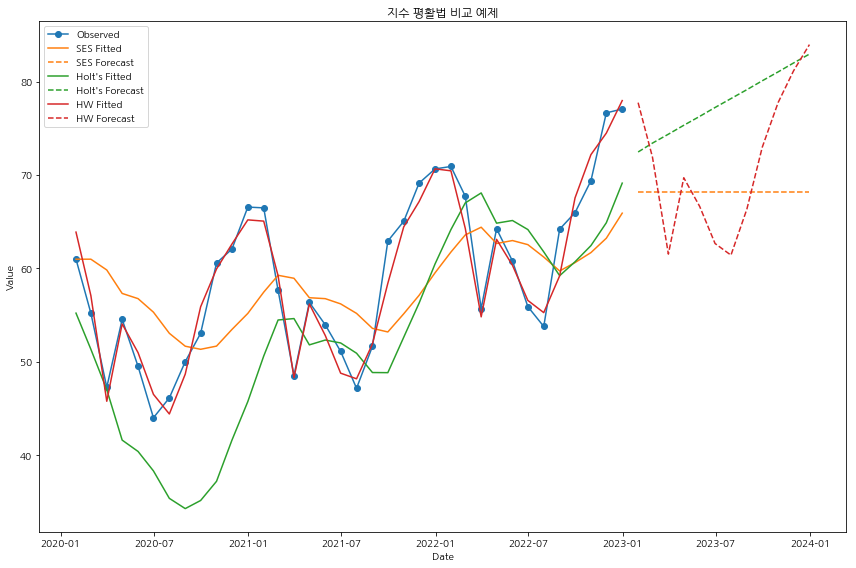

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)
import warnings
warnings.filterwarnings('ignore')

# 1. 예제 데이터 생성: 36개월(3년) 월별 시계열
np.random.seed(42)
periods = 36
date_index = pd.date_range(start='2020-01-01', periods=periods, freq='M')

# 기본 수준(level) + 선형 추세 + 계절 성분 + 잡음
level = 50
trend = 0.5  # 매월 0.5씩 증가
seasonal_pattern = np.tile([10, 5, -5, 0, -2, -8, -10, -5, 0, 5, 8, 12], 3)
noise = np.random.normal(scale=2, size=periods)

y = level + trend * np.arange(periods) + seasonal_pattern + noise
ts = pd.Series(y, index=date_index, name='value')

# 2. 단순 지수 평활법 (SES)
ses_model = SimpleExpSmoothing(ts).fit(smoothing_level=0.2, optimized=False)
ses_fitted = ses_model.fittedvalues
ses_forecast = ses_model.forecast(12)

# 3. Holt’s 선형 지수 평활법
holt_model = Holt(ts).fit(smoothing_level=0.3, smoothing_slope=0.1, optimized=False)
holt_fitted = holt_model.fittedvalues
holt_forecast = holt_model.forecast(12)

# 4. Holt–Winters 계절 지수 평활법 (Additive)
hw_model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(smoothing_level=0.2, smoothing_slope=0.1, smoothing_seasonal=0.1, optimized=False)
hw_fitted = hw_model.fittedvalues
hw_forecast = hw_model.forecast(12)

# 5. 결과 시각화
plt.figure(figsize=(12, 8))
plt.plot(ts, label='Observed', marker='o')

plt.plot(ses_fitted, label='SES Fitted', color='C1')
plt.plot(ses_forecast, label='SES Forecast', color='C1', linestyle='--')

plt.plot(holt_fitted, label="Holt's Fitted", color='C2')
plt.plot(holt_forecast, label="Holt's Forecast", color='C2', linestyle='--')

plt.plot(hw_fitted, label='HW Fitted', color='C3')
plt.plot(hw_forecast, label='HW Forecast', color='C3', linestyle='--')

plt.title('지수 평활법 비교 예제')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## 4-3. 타당도 분석


타당도(validity)란 **측정 도구**(설문지, 테스트, 평가 지표 등)가 **측정하려는 개념**을 얼마나 잘 측정하는지를 뜻함   
타당도는 크게 **내용타당도**, **구성타당도**, **준거타당도**로 구분

***

### 1. 내용타당도(Content Validity)

#### 특징  
- **전문가 평가**를 통해 측정 항목이 이론적·실제적 내용 영역을 충분히 대표하는지 판단  
- 주로 설문·척도 개발 초기 단계에 수행  

#### 장점  
- 이론적 타당한 문항 구성이 가능  
- 측정하려는 개념의 전체 범위(construct domain)를 포괄  

#### 단점  
- 정량적 지표가 아니어서 **전문가 주관** 개입  
- 전문가 간 합의가 어려울 수 있음  

#### 사용 예  
- 심리학 척도 문항 개발  
- 직무 만족도 설문 설계  
***

### 2. 구성타당도(Construct Validity)

#### 특징  
- **이론적 구성개념(construct)** 이 데이터로 잘 드러나는지 검증  
- 주로 **탐색적·확인적 요인분석(EFA, CFA)** 으로 평가  

#### 장점  
- 척도의 **잠재 요인 구조** 를 확인  
- 이론적 모델과 자료의 일치도(적합도 지표) 제공  

#### 단점  
- 충분한 표본 크기 필요 (일반적으로 표본≥200 이상 권장)  
- 모델 사양(misattribution) 오류 시 왜곡  

#### 사용 예  
- 심리검사 요인 구조 검증  
- 설문 문항 집단화 및 척도 축소  

***

### 3. 준거타당도(Criterion Validity)

준거타당도는 **측정도구 점수**와 **외부 준거(criterion)** 간 관련성으로 평가

1. **동시 타당도(Concurrent Validity)**  
   - 외부 준거와 **동일 시점**에 측정하여 상관  
2. **예측 타당도(Predictive Validity)**  
   - 외부 준거를 **미래 시점**에 측정하여 상관  

#### 장점  
- 실제 성과나 외부 지표와의 관련성 확인  
- 실무적 예측력 평가  

#### 단점  
- 외부 준거 수집 비용 및 시간 소요  
- 외부 준거 자체의 신뢰도·타당도가 필요  

#### 사용 예  
- 신입사원 평가척도 점수와 1년 후 성과 평가 상관  
- 학업성취도 검사 점수와 졸업 후 취업 성과 예측  

***

### 4. 요약 비교

| 타당도 종류     | 평가 방법                           | 장점                                  | 단점                                      |
|----------------|------------------------------------|---------------------------------------|-------------------------------------------|
| 내용타당도     | 전문가 합의(CVI)                   | 개념 범위 포괄, 초기 문항 개발 필수    | 주관 개입, 정량적 지표 제한                |
| 구성타당도     | 요인분석(EFA/CFA)                  | 잠재구조 확인, 이론·자료 일치도 평가  | 표본 크기 요구, 모델 명세 오류 위험        |
| 준거타당도     | 상관분석, 회귀분석(R²)             | 실무적 예측력, 외부 지표 관련성 검증 | 외부 준거 수집 비용·시간, 준거 자체 타당도 필요 |

타당도 분석은 **측정 도구의 신뢰도**와 함께 **측정품질**을 보장하는 핵심 단계

In [166]:
#내용타당도
import numpy as np

# 예: 5명의 전문가가 4개 문항을 1~4점(1=부적절…4=매우 적절)으로 평가
ratings = np.array([
    [4, 3, 4, 2],
    [4, 4, 3, 3],
    [3, 3, 4, 2],
    [4, 4, 4, 3],
    [3, 4, 3, 2]
])

# 각 문항의 CVI 계산 (점수 ≥3인 비율)
cvi_per_item = np.mean(ratings >= 3, axis=0)
print("문항별 CVI:", cvi_per_item)
# 전체 S-CVI/Ave (평균 CVI)
print("S-CVI/Ave:", cvi_per_item.mean())

문항별 CVI: [1.  1.  1.  0.4]
S-CVI/Ave: 0.85


- 문항 1, 2, 3의 CVI가 1.0으로 모두 “매우 적절”로 평가된 전문가 비율이 100%임을 의미
- 문항 4의 CVI는 0.4로, 전문가 중 40%만이 ‘적절’ 이상으로 평가(문항 문구에 개선이 필요)
- 네 개 문항의 CVI 평균: 0.85
  (일반적으로 S-CVI/Ave ≥ 0.80을 “양호한 내용타당도” 기준으로 보며, ≥ 0.90이면 “우수한 내용타당도”로 간주)

따라서 전체 척도는 최소한의 타당도 기준(0.80)을 충족하나, 문항 4의 낮은 CVI가 평균을 끌어내린 결과임  

척도의 내용타당도는 대체로 양호하나, 문항 4는 전문가 합의가 낮으므로  
- 문항 4의 문구를 수정하거나 삭제  
- 추가 전문가 검토를 통한 내용 보강  

In [167]:
#구성타당도
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# 예시 설문 데이터 (100명 × 6문항)
np.random.seed(0)
df = pd.DataFrame(np.random.randint(1,6,size=(100,6)), columns=[f"Q{i}" for i in range(1,7)])

# Bartlett 구형성 검정 (p<0.05면 요인분석 적합)
chi_square_value, p_value = calculate_bartlett_sphericity(df)
print("Bartlett:", chi_square_value, p_value)

# KMO 검사 (0.6 이상이면 적합)
kmo_all, kmo_model = calculate_kmo(df)
print("KMO:", kmo_model)

# 탐색적 요인분석 (주성분 방식, 요인 2개)
fa = FactorAnalyzer(n_factors=2, rotation="varimax")
fa.fit(df)
loadings = pd.DataFrame(fa.loadings_, index=df.columns, columns=["Factor1","Factor2"])
print("요인 적재량:\n", loadings)


Bartlett: 17.102423554463616 0.05905720748235598
KMO: 0.4960543217023476
요인 적재량:
      Factor1   Factor2
Q1  0.028565  0.343052
Q2  0.109273  0.059993
Q3  0.031803  0.772706
Q4  0.995813 -0.061506
Q5 -0.027631  0.099652
Q6  0.081975 -0.037605


1. Bartlett 구형성 검정  
   -  χ²(자유도) = 17.10, p = 0.059  
   -  p-값이 0.05보다 약간 크므로 귀무가설(“상관 행렬이 단위 행렬이다”)을 기각할 충분한 근거가 없음
   -  즉, 변수들 간 공분산·상관이 통계적으로 유의하게 다르다는 증거가 부족해 요인분석을 진행하기에 적합하지 않을 수 있음

2. KMO 검사  
   -  KMO = 0.496  
   -  일반적으로 KMO ≥ 0.60일 때 요인분석에 적합하다고 보며, 0.50 이하면 매우 부적합으로 간주함  
   -  따라서 본 데이터는 **요인분석을 수행하기에 전체적으로 표본 적합도가 낮은 상태**임을 의미

3. 요인 적재량  
    변수   Factor1  Factor2  
   —————————————  
    Q1    0.029    0.343  
    Q2    0.109    0.060  
    Q3    0.032    0.773  
    Q4    0.996   –0.062  
    Q5   –0.028    0.100  
    Q6    0.082   –0.038  

   -  Q4는 Factor1에 매우 높은 적재(0.996)를 보이나, 다른 변수는 두 요인 모두에서 낮은 적재량을 나타냄  
   -  Q3만 Factor2에 의미 있는 적재(0.773)를 보일 뿐, 나머지 변수들은 명확한 요인 구조를 이루지 못하고 있음

4. 종합 평가 및 권고  
   - Bartlett 검정과 KMO 지표 모두 요인분석 전제(변수 간 충분한 상관관계 및 표본 적합성)를 충족하지 못하므로,  
      - 변수 추가·제거 또는 표본 크기 확대 검토  
      - 설문 문항 문구 조정으로 변수 간 상관 강화  
     후 요인분석 재실행 필요

In [170]:
#준거타당도
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 예시: 설문 점수와 외부 준거(성과 점수)
np.random.seed(1)
n=50
survey_score = np.random.normal(50, 10, n)
performance = 0.5*survey_score + np.random.normal(0,5,n)
df = pd.DataFrame({"survey": survey_score, "perf": performance})

# 동시타당도: Pearson 상관
r, p = pearsonr(df["survey"], df["perf"])
print(f"- Concurrent Validity: r={r:.3f}, p={p:.3f}")

# 예측타당도: 간단 선형회귀 예측력(R²)
X = df[["survey"]]
y = df["perf"]
model = LinearRegression().fit(X,y)
print("- Predictive Validity R²:", r2_score(y, model.predict(X)))


- Concurrent Validity: r=0.773, p=0.000
- Predictive Validity R²: 0.5969845553179489


**Concurrent Validity**  
관측 시점에서 측정도구 점수(예: 설문 점수)와 외부 준거(동일 시점의 성과 점수) 간의 Pearson 상관계수 $r=0.773$($p<0.001$)는  
두 변수 간의 강한 양(+)의 선형관계를 의미함.  
즉, 설문 점수가 높을수록 외부 준거 점수도 높은 경향이 뚜렷하며, 이 상관이 통계적으로 유의하므로(귀무가설 $r=0$ 기각)  
측정도구의 동시 타당도가 **매우 높다**고 결론지을 수 있음

**Predictive Validity**  
선형회귀모형에서 설문 점수로 외부 준거를 예측한 결정계수 $R^2=0.5969$는 전체 변동의 약 59.7%를 설명함을 뜻함.  
즉, 설문 점수가 미래 또는 다른 시점의 성과 점수 변동의 절반 이상을 예측할 수 있어,   
측정도구의 예측 타당도가 **상당히 우수하다**고 해석됨.

“0.59밖에 안 된다”는 평가는 상대적
- 사회·행동과학 분야에서는 0.30~0.50 정도면 중간 수준의 예측력
- 의료·생물학·심리 측정 등에서는 0.40 이상이면 양호, 0.60 이상이면 높은 예측력으로 간주되는 경우가 많음